
# Soma1 (latest version from Max) Tapenade Adjoint Analysis: Serial Run


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings("ignore")

In [2]:
## analyze a sample run directory

# # 30 day run
run_dir_srl = "/scratch2/tshahriar/v4_soma_tapAdj_runs/pd_v4StP_srl_no-kpp-GM_30d_run9079/"

# # 180 day run
# run_dir_srl = "/scratch2/tshahriar/v4_soma_tapAdj_runs/pd_v4StP_srl_no-kpp-GM_180d_run9298/"

# # 180 day run with some changes in input_tap/data (with useCD)
# run_dir_srl = "/scratch2/tshahriar/v4_soma_tapAdj_runs/pd_v4StP_srl_no-kpp-GM_180d_run9333/"

# # 180 day run with diffkr added as a control
# run_dir_srl = "/scratch2/tshahriar/v4_soma_tapAdj_runs/pd_v4StP_srl_no-kpp-GM_180d_run9573/"

# 360 day run with diffkr added as a control
#run_dir_srl = "/scratch2/tshahriar/v4_soma_tapAdj_runs/pd_v4StP_srl_no-kpp-GM_360d_run9581/"

In [3]:
adxx_vars = {'adxx_theta': {'dims': ['k', 'j', 'i'],
              'attrs': {'standard_name': 'adxx_theta',
               'long_name': 'Sensitivity to Temperature',
               'units': 'dJ/K'}},
             'adxx_salt': {'dims': ['k', 'j', 'i'],
              'attrs': {'standard_name': 'adxx_salt',
               'long_name': 'Sensitivity to Salinity',
               'units': 'dJ/(g kg-1)'}},
              'adxx_diffkr': {'dims': ['k', 'j', 'i'],
              'attrs': {'standard_name': 'adxx_diffkr',
               'long_name': 'Sensitivity to Vertical Diffusivity',
               'units': 'dJ/(m2/s)'}}
            }

adj_vars = {'ADJtheta': {'dims': ['k', 'j', 'i'],
              'attrs': {'standard_name': 'adxx_theta',
               'long_name': 'Sensitivity to Temperature',
               'units': 'dJ/K'}},
             'ADJsalt': {'dims': ['k', 'j', 'i'],
              'attrs': {'standard_name': 'adxx_salt',
               'long_name': 'Sensitivity to Salinity',
               'units': 'dJ/(g kg-1)'}},
              'ADJdiffkr': {'dims': ['k', 'j', 'i'],
              'attrs': {'standard_name': 'adxx_diffkr',
               'long_name': 'Sensitivity to Vertical diffusivity',
               'units': 'dJ/(m2/s)'}}
            }

In [4]:
adxx_prefix = ['adxx_theta', 'adxx_salt', 'adxx_diffkr']
adj_prefix = ['ADJtheta', 'ADJsalt', 'ADJdiffkr']

In [5]:
ds_adxx = xmitgcm.open_mdsdataset(
    run_dir_srl,
    grid_dir=run_dir_srl,
    prefix=adxx_prefix,
    ref_date='2025-01-01',
    delta_t=1200,
    extra_variables=adxx_vars
)         

In [6]:
ds_adj = xmitgcm.open_mdsdataset(
    run_dir_srl,
    grid_dir=run_dir_srl,
    prefix=adj_prefix,
    ref_date='2025-01-01',
    delta_t=1200,
    extra_variables=adj_vars
)

OSError: Could not find the expected file prefixes ['ADJtheta', 'ADJsalt', 'ADJdiffkr'] at iternum 0. (Instead found ['ADJtheta', 'ADJsalt'])

In [ ]:
ds_adxx

In [ ]:
ds_adj

In [ ]:
ds = xr.merge([ds_adj, ds_adxx])

In [ ]:
ds

In [ ]:
ds.adxx_theta.shape, ds.adxx_theta.dims

In [ ]:
ds.adxx_diffkr.shape, ds.adxx_diffkr.dims

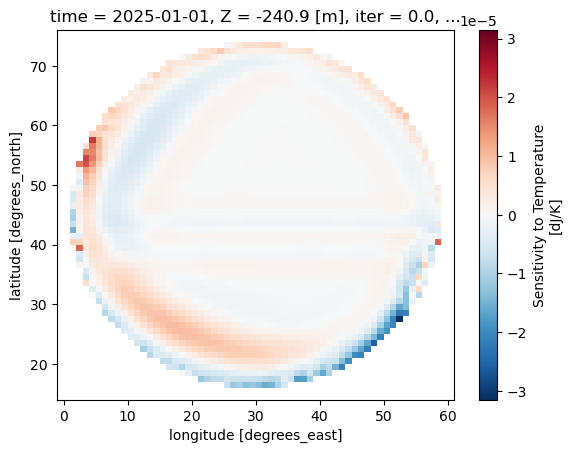

In [13]:
# Choose which time index to visualize
t_index = 0   # after 0 index, rest of the values are empty as adxx files contains the sensitivity wrt to the initial temperature only

# plotted the sensitivity field by applying the land mask. Everything in the ocean is 1 and outside ocean is 0.
ds.adxx_theta.isel(time=t_index, Z=11).where(ds.hFacC.isel(Z=11)).plot()

# #-- Uncomment lines below to control color scale and enhance contrast
# vmax = 1e-4; vmin = -vmax
# ds.adxx_theta.isel(time=t_index, Z=11).where(ds.hFacC.isel(Z=11)).plot(
#     vmin=vmin, vmax=vmax, cmap='RdBu_r'
# )

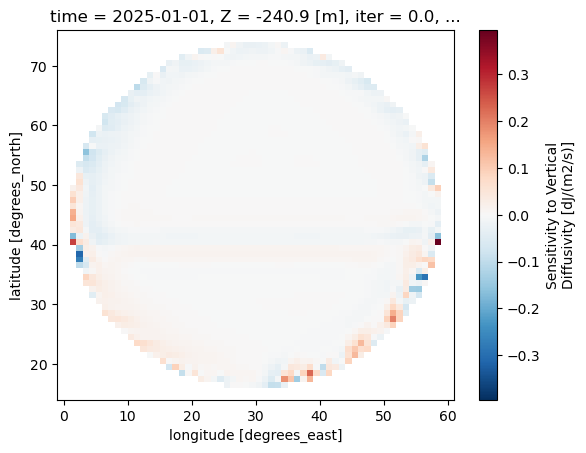

In [14]:
# Choose which time index to visualize
t_index = 0

# plotted the sensitivity field by applying the land mask. Everything in the ocean is 1 and outside ocean is 0.
ds.adxx_diffkr.isel(time=t_index, Z=11).where(ds.hFacC.isel(Z=11)).plot()

## Animation

In [15]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

### Sensitivity to Temperature

In [16]:
# --- settings ---
var  = 'ADJtheta'   
zlev = 11            # vertical level
interval_ms = 500    # time between frames (ms)

# --- slice + mask ---
da_ADJtheta = ds[var].isel(Z=zlev)
if 'hFacC' in ds:
    da_ADJtheta = da_ADJtheta.where(ds.hFacC.isel(Z=zlev) > 0) # Keep all adjoint values where there is ocean (hFacC > 0), and replace everything over land with NaN.

In [17]:
# --- robust symmetric color limits ---
A_ADJtheta = da_ADJtheta.values # the adjoint sensitivity values-a numpy array (∂J/∂Θ) at every grid cell and time step at a specific vertical level

# If any finite (non-NaN, non-inf) values exist in A, 
# compute the 99th percentile of its absolute values; otherwise, just use 1.0.
v_ADJtheta = np.nanpercentile(np.abs(A_ADJtheta), 99) if np.isfinite(A_ADJtheta).any() else 1.0
vmin_ADJtheta, vmax_ADJtheta = -v_ADJtheta, v_ADJtheta

In [18]:
## for understanding

print("Shape of A_ADJtheta:", A_ADJtheta.shape)
print("Data type:", A_ADJtheta.dtype)
print("Total elements:", A_ADJtheta.size)

# Count valid (finite) values
finite_mask = np.isfinite(A_ADJtheta)
num_finite = np.count_nonzero(finite_mask)
print("Finite values:", num_finite)
print("NaNs or Infs:", A_ADJtheta.size - num_finite)

if num_finite > 0:
    Af = A_ADJtheta[finite_mask]  # flatten and remove NaNs/Infs
    print(f"\nMin:  {Af.min():.3e}")
    print(f"Max:  {Af.max():.3e}")
    print(f"Mean: {Af.mean():.3e}")
    print(f"Std:  {Af.std():.3e}")

    # Print useful percentiles of absolute values
    percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
    abs_perc = np.nanpercentile(np.abs(Af), percentiles)
    print("\nPercentiles of |A_ADJtheta|:")
    for p, v in zip(percentiles, abs_perc):
        print(f" {p:>5.1f}th percentile: {v:.3e}")
else:
    print("\n⚠️ No finite values found in A_ADJtheta.")

Shape of A_ADJtheta: (72, 62, 62)
Data type: float32
Total elements: 276768
Finite values: 189504
NaNs or Infs: 87264

Min:  -2.060e-04
Max:  1.370e-04
Mean: 6.455e-08
Std:  6.496e-06

Percentiles of |A_ADJtheta|:
   0.0th percentile: 6.634e-13
   1.0th percentile: 1.509e-09
   5.0th percentile: 7.187e-09
  25.0th percentile: 1.197e-07
  50.0th percentile: 7.347e-07
  75.0th percentile: 2.851e-06
  95.0th percentile: 1.158e-05
  99.0th percentile: 2.516e-05
  99.9th percentile: 6.699e-05
 100.0th percentile: 2.060e-04


In [19]:
# helper for readable time label
tcoord_ADJtheta = da_ADJtheta['time'].values # we grab the time coordinate from your DataArray da_ADJtheta

def tlabel(i):
    try:
        return str(np.datetime_as_string(tcoord_ADJtheta[i], unit='D')) # YYYY-MM-DD only
    except Exception:
        return str(tcoord_ADJtheta[i])

In [20]:
# ## for understanding

# tcoord_ADJtheta

In [21]:
# --- figure setup ---
fig, ax = plt.subplots(figsize=(10, 6))

# first frame
h = da_ADJtheta.isel(time=0).plot(
    x='XC', y='YC', cmap='RdBu_r',
    vmin=vmin_ADJtheta, vmax=vmax_ADJtheta,
    add_colorbar=True, ax=ax
)

title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
ax.set_xlabel('Longitude (degrees east)')
ax.set_ylabel('Latitude (degrees north)')

# --- update function ---
def update(i):
    ax.clear()
    da_ADJtheta.isel(time=i).plot(
        x='XC', y='YC', cmap='RdBu_r',
        vmin=vmin_ADJtheta, vmax=vmax_ADJtheta,
        add_colorbar=False, ax=ax
    )
    ax.set_title(f"{var} • Z={zlev} • time={tlabel(i)}")
    ax.set_xlabel('Longitude (degrees east)')
    ax.set_ylabel('Latitude (degrees north)')
    return ax

# Create a reversed list of frame indices: [N-1, ..., 2, 1, 0]
frames = list(reversed(range(da_ADJtheta.sizes['time'])))

# --- Create and display animation ---

# The FuncAnimation function builds the animation by repeatedly calling our `update()` function.
# Each call updates the figure for one frame (one time step) in the dataset.
# Arguments:
#   fig        → the Matplotlib figure we created earlier (our plotting canvas)
#   update     → the function that draws each new frame (defined above)
#   frames     → total number of frames to animate; here equal to the number of time steps in `da`
#   interval   → delay between frames in milliseconds (controls playback speed)
#   blit=False → redraws the entire plot every frame; safer and more compatible in Jupyter notebooks
#
# Internally, this will:
#   1. Start from the base figure
#   2. Loop over each time index i = 0, 1, 2, ..., N-1
#   3. Call update(i) to draw the i-th time slice
#   4. Wait `interval_ms` milliseconds before the next frame
#
# `plt.close(fig)` prevents the static (non-animated) version of the figure from appearing above the animation.
#
# `HTML(anim.to_jshtml())` converts the animation to an interactive JavaScript-based HTML element
# so that it plays inline directly inside the Jupyter notebook.
#
# Result: a smooth, inline animation that shows how the adjoint field evolves over time.

# --- create animation ---
anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=interval_ms,
    blit=False
)

plt.close(fig)
HTML(anim.to_jshtml())

<IPython.core.display.HTML object>
[text/html animation output (3.5 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [22]:
# html = anim.to_jshtml()
# with open("ADJtheta_40N_Z11_360d.html", "w") as f:
#     f.write(html)

Note about the Above Plot

I had to plot the ADJtheta file in the reverse order of the timestep. This is because, ami forward model er time step use kortesi ADJtheta file k numbering korar jonno. But adjoint runs backward in time. So jokhon plot korbo tokhon seta ke reverse timestep order e plot korte hobe.

"ADJtheta.0000000000.data" data in this file should closely corresponds to the data in the file "adxx_theta.0000000000.data"


### Sensitivity to Vertical Diffusivity

In [23]:
# --- settings ---
var  = 'ADJdiffkr'   
zlev = 11            # vertical level
interval_ms = 500    # time between frames (ms)

# --- slice + mask ---
da_ADJdiffkr = ds[var].isel(Z=zlev)
if 'hFacC' in ds:
    da_ADJdiffkr = da_ADJdiffkr.where(ds.hFacC.isel(Z=zlev) > 0) # Keep all adjoint values where there is ocean (hFacC > 0), and replace everything over land with NaN.

In [24]:
# --- robust symmetric color limits ---
A_ADJdiffkr = da_ADJdiffkr.values # the adjoint sensitivity values-a numpy array (∂J/∂Θ) at every grid cell and time step at a specific vertical level

# If any finite (non-NaN, non-inf) values exist in A, 
# compute the 99th percentile of its absolute values; otherwise, just use 1.0.
v_ADJdiffkr = np.nanpercentile(np.abs(A_ADJdiffkr), 99) if np.isfinite(A_ADJdiffkr).any() else 1.0
vmin_ADJdiffkr, vmax_ADJdiffkr = -v_ADJdiffkr, v_ADJdiffkr

In [25]:
## for understanding

print("Shape of A_ADJdiffkr:", A_ADJdiffkr.shape)
print("Data type:", A_ADJdiffkr.dtype)
print("Total elements:", A_ADJdiffkr.size)

# Count valid (finite) values
finite_mask = np.isfinite(A_ADJdiffkr)
num_finite = np.count_nonzero(finite_mask)
print("Finite values:", num_finite)
print("NaNs or Infs:", A_ADJdiffkr.size - num_finite)

if num_finite > 0:
    Af = A_ADJdiffkr[finite_mask]  # flatten and remove NaNs/Infs
    print(f"\nMin:  {Af.min():.3e}")
    print(f"Max:  {Af.max():.3e}")
    print(f"Mean: {Af.mean():.3e}")
    print(f"Std:  {Af.std():.3e}")

    # Print useful percentiles of absolute values
    percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
    abs_perc = np.nanpercentile(np.abs(Af), percentiles)
    print("\nPercentiles of |A_ADJdiffkr|:")
    for p, v in zip(percentiles, abs_perc):
        print(f" {p:>5.1f}th percentile: {v:.3e}")
else:
    print("\n⚠️ No finite values found in A_ADJdiffkr.")

Shape of A_ADJdiffkr: (72, 62, 62)
Data type: float32
Total elements: 276768
Finite values: 189504
NaNs or Infs: 87264

Min:  -3.255e-01
Max:  3.944e-01
Mean: -4.716e-04
Std:  1.874e-02

Percentiles of |A_ADJdiffkr|:
   0.0th percentile: 1.500e-09
   1.0th percentile: 1.423e-06
   5.0th percentile: 4.759e-06
  25.0th percentile: 3.634e-05
  50.0th percentile: 6.596e-04
  75.0th percentile: 4.668e-03
  95.0th percentile: 2.851e-02
  99.0th percentile: 8.546e-02
  99.9th percentile: 2.144e-01
 100.0th percentile: 3.944e-01


In [26]:
# helper for readable time label
tcoord_ADJdiffkr = da_ADJdiffkr['time'].values # we grab the time coordinate from your DataArray da

def tlabel(i):
    try:
        return str(np.datetime_as_string(tcoord_ADJdiffkr[i], unit='D')) # YYYY-MM-DD only
    except Exception:
        return str(tcoord[i])

In [27]:
# --- figure setup ---
fig, ax = plt.subplots(figsize=(10, 6))

# first frame
h = da_ADJdiffkr.isel(time=0).plot(
    x='XC', y='YC', cmap='RdBu_r',
    vmin=vmin_ADJdiffkr, vmax=vmax_ADJdiffkr,
    add_colorbar=True, ax=ax
)

title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
ax.set_xlabel('Longitude (degrees east)')
ax.set_ylabel('Latitude (degrees north)')

# --- update function ---
def update(i):
    ax.clear()
    da_ADJdiffkr.isel(time=i).plot(
        x='XC', y='YC', cmap='RdBu_r',
        vmin=vmin_ADJdiffkr, vmax=vmax_ADJdiffkr,
        add_colorbar=False, ax=ax
    )
    ax.set_title(f"{var} • Z={zlev} • time={tlabel(i)}")
    ax.set_xlabel('Longitude (degrees east)')
    ax.set_ylabel('Latitude (degrees north)')
    return ax

# Create a reversed list of frame indices: [N-1, ..., 2, 1, 0]
frames = list(reversed(range(da_ADJdiffkr.sizes['time'])))

# --- Create and display animation ---

# The FuncAnimation function builds the animation by repeatedly calling our `update()` function.
# Each call updates the figure for one frame (one time step) in the dataset.
# Arguments:
#   fig        → the Matplotlib figure we created earlier (our plotting canvas)
#   update     → the function that draws each new frame (defined above)
#   frames     → total number of frames to animate; here equal to the number of time steps in `da`
#   interval   → delay between frames in milliseconds (controls playback speed)
#   blit=False → redraws the entire plot every frame; safer and more compatible in Jupyter notebooks
#
# Internally, this will:
#   1. Start from the base figure
#   2. Loop over each time index i = 0, 1, 2, ..., N-1
#   3. Call update(i) to draw the i-th time slice
#   4. Wait `interval_ms` milliseconds before the next frame
#
# `plt.close(fig)` prevents the static (non-animated) version of the figure from appearing above the animation.
#
# `HTML(anim.to_jshtml())` converts the animation to an interactive JavaScript-based HTML element
# so that it plays inline directly inside the Jupyter notebook.
#
# Result: a smooth, inline animation that shows how the adjoint field evolves over time.

# --- create animation ---
anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=interval_ms,
    blit=False
)

plt.close(fig)
HTML(anim.to_jshtml())

<IPython.core.display.HTML object>
[text/html animation output (4.1 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [28]:
# html = anim.to_jshtml()
# with open("ADJdiffkr_40N_Z11_360d.html", "w") as f:
#     f.write(html)

### Sensitivity

### Sensitivity